In [134]:
import argparse
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REQUIRED_COLUMNS = {
    "t",
    "t_prime",
    "center_site",
    "site_index",
    "real_part",
    "imaginary_part",
}

def load_twotime_csv(
    input_path: Path,
) -> dict[tuple[float, float, int, int], complex]:
    """
    Load CSV data as:

        {
            (t, tprime, center_site, site): complex_value
        }
    """

    if not input_path.is_file():
            raise FileNotFoundError(f"CSV file not found: {input_path}")
    data = {}

    with input_path.open("r", newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)

        for row in reader:
            key = (
                float(row["t"]),
                float(row["t_prime"]),
                int(row["center_site"]),
                int(row["site_index"]),
            )

            data[key] = complex(
                float(row["real_part"]),
                float(row["imaginary_part"]),
            )

    return data



In [ ]:
def compute_fourier_transform_omega_chain(
    data: dict[tuple[float, float, int, int], complex],
    omega: np.ndarray,
    gamma: float,
    t_probe: float,
    center_site: int,
    reference_site: int,
    time_axis: np.ndarray,
) -> np.ndarray:
    """
    Compute the full two-time transform of G(t, t')
    """

    omega = np.asarray(omega, dtype=float)
    time_axis = np.asarray(time_axis, dtype=float)

    probe_matches = np.flatnonzero(
        np.isclose(time_axis, t_probe)
    )

    if probe_matches.size == 0:
        raise ValueError(
            f"t_probe={t_probe} is not present in time_axis"
        )

    selected_times = time_axis[probe_matches[0]:]
    number_of_times = selected_times.size

    green_matrix = np.empty(
        (number_of_times, number_of_times),
        dtype=np.complex128,
    )

    # Fill the stored upper triangle: t_prime >= t.
    t_indices, t_prime_indices = np.triu_indices(
        number_of_times
    )

    for t_index, t_prime_index in zip(
        t_indices,
        t_prime_indices,
    ):
        t = float(selected_times[t_index])
        t_prime = float(selected_times[t_prime_index])

        green_matrix[t_index, t_prime_index] = data[
            (
                t,
                t_prime,
                center_site,
                reference_site,
            )
        ]



    # Reconstruct the lower time triangle.
    t_indices, t_prime_indices = np.tril_indices(
        number_of_times,
        k=-1
    )

    for t_index, t_prime_index in zip(
        t_indices,
        t_prime_indices,
    ):
        t = float(selected_times[t_index])
        t_prime = float(selected_times[t_prime_index])

        reversed_value = data[
            (
                t_prime,
                t,
                center_site,
                reference_site,
            )
        ]

        green_matrix[t_index, t_prime_index] = (
            -np.conj(reversed_value)
        )

    t_values = selected_times[:, None]
    t_prime_values = selected_times[None, :]

    damping = np.exp(
        -gamma * (t_values - t_probe)
        -gamma * (t_prime_values - t_probe)
    )

    time_differences = t_values - t_prime_values
    weighted_green = green_matrix * damping

    phase = np.exp(
        1j
        * np.outer(
            omega,
            time_differences.ravel(),
        )
    )

    green_omega = phase @ weighted_green.ravel()

    return -1j * green_omega

In [136]:
csv_path = Path("/Users/qqt/Library/CloudStorage/OneDrive-OakRidgeNationalLaboratory/Research_Projects/r_stcvsttc/code/template_folder/N=6_Nup=3_Ndown=3_20260924_130122/twotime_N=6_Nup=3_Ndown=3_20260924_153015/N=6_Nup=3_Ndown=3_20260924_153015_P2_c_P3_centersite=2.csv")

data = load_twotime_csv(csv_path)

pump_table_path = Path(
    "/Users/qqt/Library/CloudStorage/OneDrive-OakRidgeNationalLaboratory/"
    "Research_Projects/r_stcvsttc/code/template_folder/"
    "N=6_Nup=3_Ndown=3_20260924_130122/"
    "td_N=6_Nup=3_Ndown=3_20260924_153015/pump_table.csv"
)

with pump_table_path.open("r", newline="", encoding="utf-8") as file:
    pump_table = list(csv.DictReader(file))

time_axis = np.array([float(row["time"]) for row in pump_table])


omega_start = -10.0
omega_end = 10.0
omega_points = 1001 
eta = 1.0
t_probe = 10.0

omega = np.linspace(omega_start, omega_end, omega_points)



green_omega = compute_fourier_transform_omega_chain(
    data=data,
    omega=omega,
    gamma=eta,
    t_probe=t_probe,
    center_site=2,
    reference_site=3,
    time_axis=time_axis,
    number_of_sites=6
)

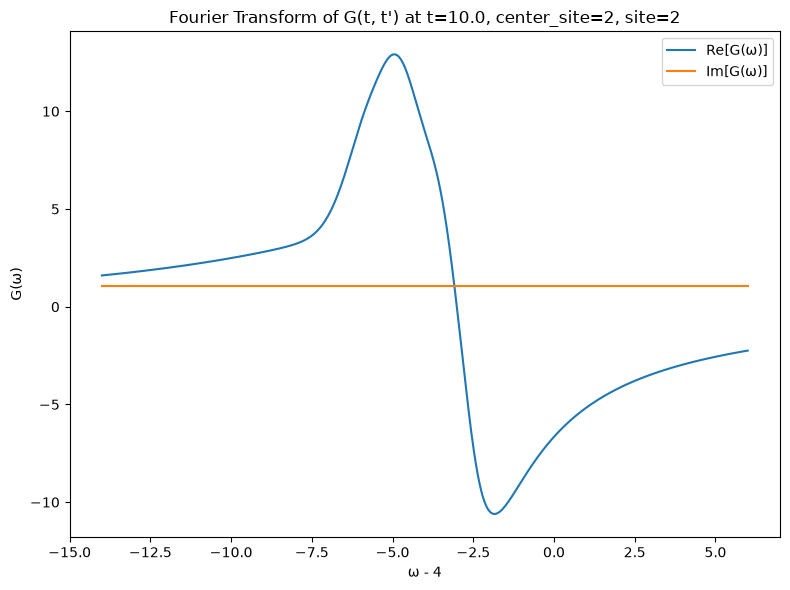

In [137]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    omega-4,
    green_omega.real,
    label="Re[G(ω)]",
)
ax.plot(
    omega-4,
    -green_omega.imag,
    label="Im[G(ω)]",
)
ax.set_xlabel("ω - 4")
ax.set_ylabel("G(ω)")
ax.set_title(f"Fourier Transform of G(t, t') at t={t_probe}, center_site=2, site=2")
ax.legend()
plt.tight_layout()

In [138]:
def compute_gkomega(
    data: dict[tuple[float, float, int, int], complex],
    k_axis: np.ndarray,
    omega: np.ndarray,
    gamma: float,
    t_probe: float,
    center_site: int,
    time_axis: np.ndarray,
) -> np.ndarray:
    """
    Compute G(k, omega) for a one-dimensional chain.

    Returns
    -------
    g_komega
        Complex array with shape (len(k_axis), len(omega)).
        Axis 0 corresponds to momentum and axis 1 to frequency.
    """

    k_axis = np.asarray(k_axis, dtype=float)
    omega = np.asarray(omega, dtype=float)
    time_axis = np.asarray(time_axis, dtype=float)

    probe_matches = np.flatnonzero(np.isclose(time_axis, t_probe))
    if probe_matches.size == 0:
        raise ValueError(f"t_probe={t_probe} is not present in time_axis")

    selected_times = time_axis[probe_matches[0] :]

    # All time pairs satisfying t_prime >= t.
    t_indices, t_prime_indices = np.triu_indices(selected_times.size)

    t_values = selected_times[t_indices]
    t_prime_values = selected_times[t_prime_indices]
    time_differences = t_values - t_prime_values

    # Find all chain sites available for this center site.
    sites = np.asarray(
        sorted(
            {
                site
                for _, _, stored_center, site in data
                if stored_center == center_site
            }
        ),
        dtype=int,
    )

    if sites.size == 0:
        raise ValueError(f"No data found for center_site={center_site}")

    # Shape: (number of sites, number of time pairs)
    green_site_time = np.empty(
        (sites.size, t_values.size),
        dtype=np.complex128,
    )

    for site_index, site in enumerate(sites):
        green_site_time[site_index] = np.fromiter(
            (
                data[
                    (
                        float(t),
                        float(t_prime),
                        center_site,
                        int(site),
                    )
                ]
                for t, t_prime in zip(t_values, t_prime_values)
            ),
            dtype=np.complex128,
            count=t_values.size,
        )

    damping = np.exp(
        -gamma * (t_values - t_probe)
        -gamma * (t_prime_values - t_probe)
    )

    # Shape: (number of frequencies, number of time pairs)
    temporal_phase = np.exp(
        1j * np.outer(omega, time_differences)
    )

    # First transform time coordinates.
    # Result shape: (number of sites, number of frequencies)
    green_site_omega = (
        green_site_time * damping[None, :]
    ) @ temporal_phase.T

    relative_positions = sites - center_site

    # Shape: (number of momenta, number of sites)
    spatial_phase = np.exp(
        -1j * np.outer(k_axis, relative_positions)
    )

    # Shape: (number of momenta, number of frequencies)
    return spatial_phase @ green_site_omega * (-1.0j)

number_of_sites = 6
gamma = 1.0
center_site = 2
k_axis = 2.0 * np.pi * np.arange(number_of_sites) / number_of_sites


k_axis = np.linspace(
    -np.pi,
    np.pi,
    number_of_sites,
    endpoint=True,
)



g_komega = compute_gkomega(
    data=data,
    k_axis=k_axis,
    omega=omega,
    gamma=gamma,
    t_probe=t_probe,
    center_site=center_site,
    time_axis=time_axis,
)

spectral_function = -np.imag(g_komega) / np.pi



# Map k into [-pi, pi).
k_wrapped = (k_axis + np.pi) % (2.0 * np.pi) - np.pi

# Sort momentum and reorder G(k, omega) identically.
k_order = np.argsort(k_wrapped)
k_wrapped = k_wrapped[k_order]
g_komega_wrapped = g_komega[k_order]

spectral_function = -np.imag(g_komega_wrapped) / np.pi



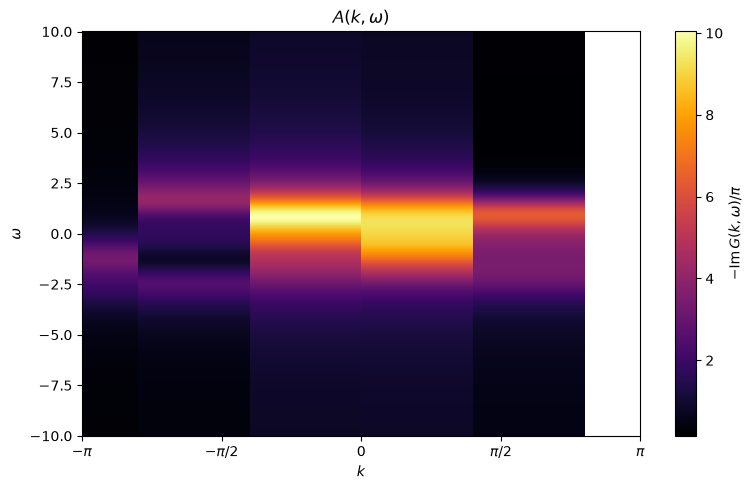

In [139]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

image = ax.pcolormesh(
    k_wrapped,
    omega,
    spectral_function.T,
    shading="auto",
    cmap="inferno",
)

ax.set_xlim(-np.pi, np.pi)
ax.set_xticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    [
        r"$-\pi$",
        r"$-\pi/2$",
        r"$0$",
        r"$\pi/2$",
        r"$\pi$",
    ],
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$\omega$")
ax.set_title(r"$A(k,\omega)$")

fig.colorbar(
    image,
    ax=ax,
    label=r"$-\mathrm{Im}\,G(k,\omega)/\pi$",
)

fig.tight_layout()
plt.show()